# Homopolymer length-stratified downsample accuracy (HCT116)

Compare phylogenetic accuracy vs. number of MS targets across homopolymer length bins.

**Prerequisite:** run downsample jobs first:
```bash
cd downsample_targets/homopolymer_length_stratified
bash run_all.sh
```

## Main finding
- **12–14 bp** homopolymers give the highest phylogenetic accuracy (sweet spot); 95% CIs do not overlap with any other bin at 100–200 targets
- **10–11 bp, 15–17 bp, and 18–50 bp** have overlapping 95% CIs at most target counts → **not significantly different from each other** in this analysis (despite different point estimates)
- Do **not** claim a monotonic "longer = worse" trend from this figure alone

## Bins plotted
`10-11bp`, `12-14bp`, `15-17bp`, `18-50bp`

In [1]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Paths

In [2]:
# All inputs/outputs use absolute paths so this notebook can be copied to
# software/RETrace2/notebooks/ and run without depending on the working directory.
DATA_DIR = '/home/tony/Scratch/RETrace2/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp'
STRAT_DIR = os.path.join(DATA_DIR, 'downsample_targets', 'homopolymer_length_stratified')
RUNS_DIR = os.path.join(STRAT_DIR, 'runs')
if not os.path.isdir(RUNS_DIR):
    raise FileNotFoundError(f'RUNS_DIR not found: {RUNS_DIR}')

LENGTH_BINS = [
    '10-11bp',
    '12-14bp',
    '15-17bp',
    '18-50bp',
]

data_dict = {
    bin_name: os.path.join(RUNS_DIR, bin_name, 'output')
    for bin_name in LENGTH_BINS
}

missing = [f'{name}: {path}' for name, path in data_dict.items() if not os.path.isdir(path)]
if missing:
    raise FileNotFoundError('Missing downsample result directories:\n' + '\n'.join(missing))

figure_dir = STRAT_DIR
print('DATA_DIR:', DATA_DIR)
print('STRAT_DIR:', STRAT_DIR)
print('figure_dir:', figure_dir)

## Load downsample results

In [3]:
def get_downsample_stat(eval_path):
    build_path = eval_path.removesuffix('.evalPhylo.txt') + '.buildPhylo.stats.txt'
    filename = os.path.basename(eval_path)
    # e.g. ...10-11bp.HipSTR.100.0.evalPhylo.txt
    match = re.search(r'\.HipSTR\.(\d+)\.(\d+)\.evalPhylo\.txt$', filename)
    if not match:
        raise ValueError(f'Cannot parse n_target/seed from filename: {filename}')
    n_target = int(match.group(1))
    seed = int(match.group(2))

    df = pd.read_csv(eval_path, sep='\t', index_col=0)
    all_accuracy = float(df.at['All_Distances', 'Percent_Accuracy']) * 100

    n_sample = None
    n_target_pair = None
    if os.path.exists(build_path):
        with open(build_path) as handle:
            for line in handle:
                if line.startswith('Number of Samples Analyzed'):
                    n_sample = int(re.findall(r'[0-9]+', line)[0])
                if line.startswith('Avg targets shared per pair of cells'):
                    n_target_pair = float(re.findall(r'[0-9]+\.[0-9]+', line)[0])

    return {
        'eval_path': eval_path,
        'n_target': n_target,
        'seed': seed,
        'all_accuracy': all_accuracy,
        'n_target_pair': n_target_pair,
        'n_sample': n_sample,
    }

In [4]:
df_list = []
missing_bins = []

for bin_name, output_dir in data_dict.items():
    eval_paths = sorted(glob.glob(os.path.join(output_dir, '*evalPhylo.txt')))
    if not eval_paths:
        missing_bins.append(bin_name)
        continue
    df = pd.DataFrame([get_downsample_stat(path) for path in eval_paths])
    df['group'] = bin_name
    df_list.append(df)

if missing_bins:
    print('No evalPhylo.txt yet for:', missing_bins)

if not df_list:
    raise RuntimeError('No downsample results found. Run bash run_all.sh first.')

df_combined = pd.concat(df_list, ignore_index=True)
df_combined_filtered = df_combined.query('n_sample >= 30').copy()

# Keep only target counts where every plotted group has data.
# Cap at 200 targets (exclude 250) — see markdown notes in next cell.
MAX_TARGET = 200
groups_present = [b for b in LENGTH_BINS if b in df_combined_filtered['group'].unique()]
common_targets = sorted(
    set.intersection(*[
        set(df_combined_filtered.loc[df_combined_filtered['group'] == b, 'n_target'])
        for b in groups_present
    ])
)
common_targets = [t for t in common_targets if t <= MAX_TARGET]
print(f'Plotting shared target counts (all groups, <= {MAX_TARGET}): {common_targets}')

df_plot = df_combined_filtered[df_combined_filtered['n_target'].isin(common_targets)].copy()
df_plot.head()

Plotting shared target counts (all groups, <= 200): [100, 150, 200]


,eval_path,n_target,seed,all_accuracy,n_target_pair,n_sample,group
0,/media/scratchSSD/tony_tmp/RETrace2/20230117_N...,100,0,36.035662,9.0,41,10-11bp
1,/media/scratchSSD/tony_tmp/RETrace2/20230117_N...,100,1,39.166494,9.3,41,10-11bp
2,/media/scratchSSD/tony_tmp/RETrace2/20230117_N...,100,10,40.431267,9.8,41,10-11bp
3,/media/scratchSSD/tony_tmp/RETrace2/20230117_N...,100,11,39.062824,9.3,41,10-11bp
4,/media/scratchSSD/tony_tmp/RETrace2/20230117_N...,100,12,32.904831,9.3,41,10-11bp


## Notes for publication

- **Dataset:** HCT116 library sequenced 2021–2023 on Illumina NovaSeq 6000, before PCR/SeqAMP/AVITI optimizations in Fig. 2.
- **Target cap (200):** At 250 targets, downsampling drops cells without enough length-stratified loci, changing the analyzed cohort. Plots use 100–200 targets where cell numbers are stable.
- **CI interpretation:** Only 12–14 bp is clearly separated from other bins; the remaining groups have overlapping 95% CIs and should be described as similar.

## Summary table

In [5]:
summary = (
    df_plot
    .groupby('group')
    .agg(n_iterations=('all_accuracy', 'size'),
         n_targets_min=('n_target', 'min'),
         n_targets_max=('n_target', 'max'),
         mean_accuracy_at_max_targets=('all_accuracy', 'mean'))
    .reset_index()
)
summary

,group,n_iterations,n_targets_min,n_targets_max,mean_accuracy_at_max_targets
0,10-11bp,90,100,200,40.669132
1,12-14bp,90,100,200,56.290575
2,15-17bp,90,100,200,44.817975
3,18-50bp,90,100,200,46.328651


## Plot: accuracy vs number of targets

Same style as `06_HCT116_DownsampleAccuracy_homopolymer10-14bp_vs_15to50bp.ipynb`.
Lineplot shows mean ± 95% CI across 30 random downsample seeds.

**Read the CIs, not just the lines:** only 12–14 bp is clearly separated; other bins have overlapping intervals and should be treated as similar.

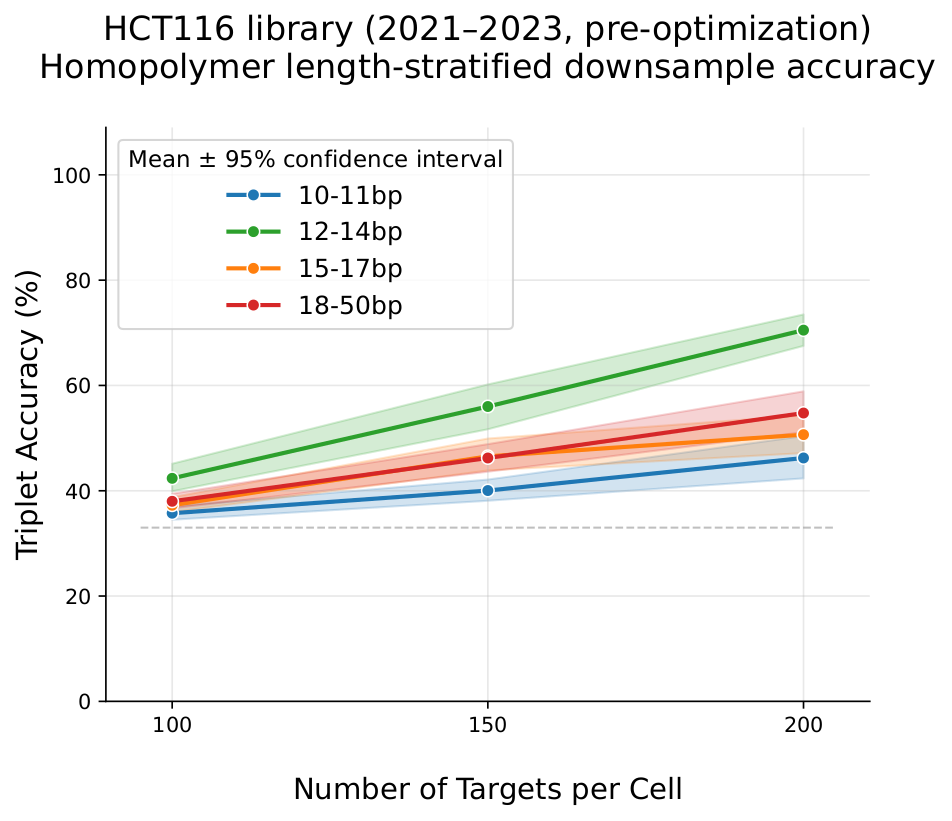

In [6]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Match notebook 06 palette style (tab colors); 12-14bp uses tab:green as in original sweet-spot comparison
bin_order = [b for b in LENGTH_BINS if b in df_plot['group'].unique()]
custom_colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red'][: len(bin_order)]

sns.lineplot(
    data=df_plot, x='n_target', y='all_accuracy',
    hue='group', hue_order=bin_order, palette=custom_colors, ax=ax,
    marker='o', markersize=6, linewidth=2,
)

ax.set_title(
    'HCT116 library (2021–2023, pre-optimization)\n'
    'Homopolymer length-stratified downsample accuracy\n',
    fontsize=16,
)
ax.set_ylabel('Triplet Accuracy (%)', fontsize=14)
ax.set_xlabel('\nNumber of Targets per Cell', fontsize=14)

ax.grid(True, alpha=0.3)
ax.set_ylim(0, 109)
ax.set_xticks(np.arange(100, 201, 50))

# Add horizontal reference line at 33% accuracy
ax.hlines(33, ax.get_xlim()[0], ax.get_xlim()[1], color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(
    fontsize=12,
    loc="upper left",
    title="Mean ± 95% confidence interval",
    title_fontsize=11,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    os.path.join(figure_dir, 'HCT116_homopolymer_length_stratified_downsample_accuracy.pdf'),
    dpi=200,
    bbox_inches='tight',
    pad_inches=0.1,
)
plt.show()

## Optional: regression slopes per bin

In [7]:
import numpy as np

rows = []
for group in bin_order:
    sub = df_plot[df_plot['group'] == group]
    slope, intercept = np.polyfit(sub['n_target'], sub['all_accuracy'], 1)
    rows.append({'group': group, 'slope': slope, 'intercept': intercept})

pd.DataFrame(rows).sort_values('slope', ascending=False)

,group,slope,intercept
1,12-14bp,0.281443,14.074112
3,18-50bp,0.167665,21.178872
2,15-17bp,0.134024,24.714331
0,10-11bp,0.104917,24.931520


## Plot: 200 targets per cell (30 random downsamples)

Each dot is one of **30 random downsample iterations** (`seed` 0–29) at **200 targets per cell**. Boxplots summarize the spread across those iterations, compared across homopolymer length bins (ordered by length).

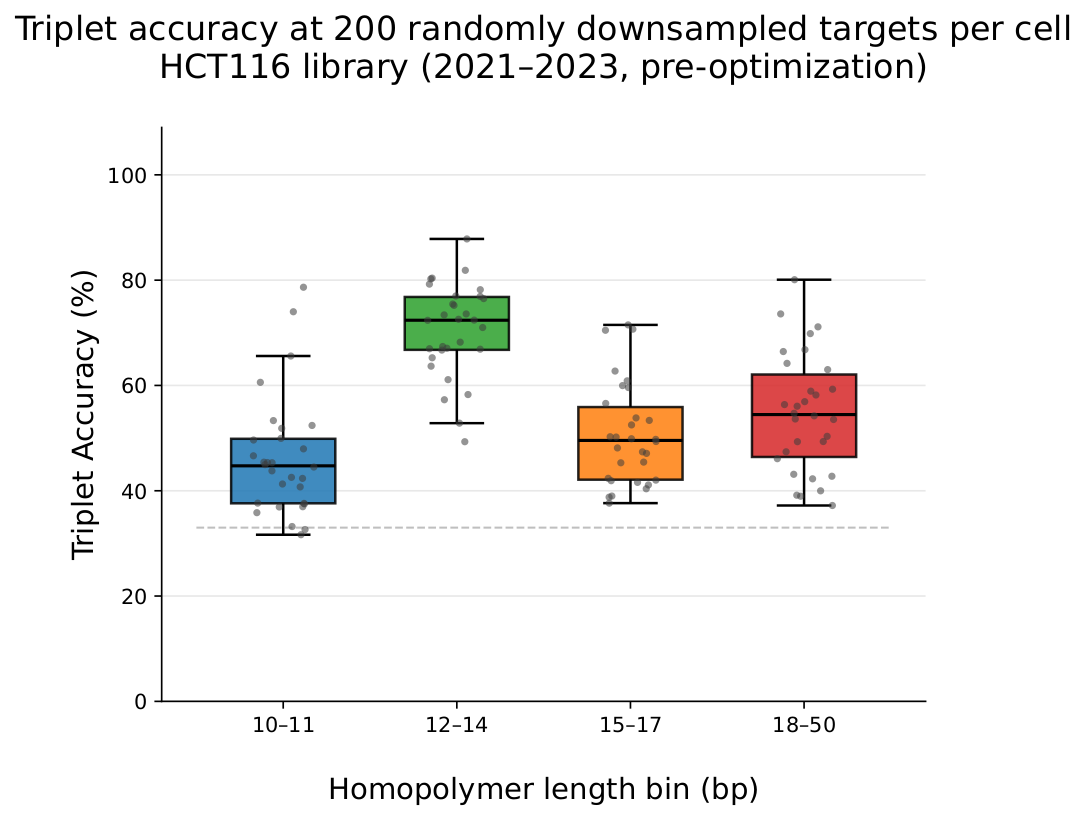

In [8]:
TARGET_N = 200
bin_order = [b for b in LENGTH_BINS if b in df_combined_filtered['group'].unique()]
bin_labels = ['10–11', '12–14', '15–17', '18–50'][: len(bin_order)]
custom_colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red'][: len(bin_order)]

df_200 = (
    df_combined_filtered
    .query('n_target == @TARGET_N and n_sample >= 30')
    .copy()
)
df_200['bin_label'] = pd.Categorical(
    df_200['group'].map(dict(zip(bin_order, bin_labels))),
    categories=bin_labels,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

sns.boxplot(
    data=df_200,
    x='bin_label',
    y='all_accuracy',
    order=bin_labels,
    ax=ax,
    width=0.6,
    linewidth=1.2,
    fliersize=0,
    color='white',
    boxprops=dict(edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5),
)
for patch, color in zip(ax.patches, custom_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.85)

sns.stripplot(
    data=df_200,
    x='bin_label',
    y='all_accuracy',
    order=bin_labels,
    color='#3d3d3d',
    alpha=0.55,
    size=3.5,
    jitter=0.18,
    ax=ax,
    zorder=3,
)

ax.set_title(
    f'Triplet accuracy at {TARGET_N} randomly downsampled targets per cell\n'
    'HCT116 library (2021–2023, pre-optimization)\n',
    fontsize=16,
)
ax.set_xlabel('\nHomopolymer length bin (bp)', fontsize=14)
ax.set_ylabel('Triplet Accuracy (%)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 109)
ax.hlines(33, -0.5, len(bin_labels) - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    os.path.join(figure_dir, 'HCT116_homopolymer_length_stratified_200targets_by_bin.pdf'),
    dpi=200,
    bbox_inches='tight',
    pad_inches=0.1,
)
plt.show()

## Statistical comparison at 200 targets per cell

Formal comparison of tree accuracy across homopolymer length bins using the 30 downsample iterations shown above.

- **Descriptive statistics** per bin
- **Pairwise Mann–Whitney U** tests with **Bonferroni** correction for 6 comparisons

In [9]:
from itertools import combinations

from scipy import stats
from statsmodels.stats.multitest import multipletests

stats_bins = [b for b in LENGTH_BINS if b in df_200['group'].unique()]

desc = (
    df_200.groupby('group', observed=True)['all_accuracy']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    .reindex(stats_bins)
    .round(2)
)
print('Descriptive statistics (tree accuracy %, n = 30 seeds per bin)')
display(desc)

pairwise_rows = []
for group_a, group_b in combinations(stats_bins, 2):
    x = df_200.loc[df_200['group'] == group_a, 'all_accuracy']
    y = df_200.loc[df_200['group'] == group_b, 'all_accuracy']
    _, p_raw = stats.mannwhitneyu(x, y, alternative='two-sided')
    higher_group = group_a if x.median() > y.median() else group_b
    pairwise_rows.append({
        'group_a': group_a,
        'group_b': group_b,
        'median_a': x.median(),
        'median_b': y.median(),
        'higher_median': higher_group,
        'p_raw': p_raw,
    })

pairwise = pd.DataFrame(pairwise_rows)
n_comparisons = len(pairwise)
_, p_bonferroni, _, _ = multipletests(pairwise['p_raw'], method='bonferroni')
pairwise['p_bonferroni'] = p_bonferroni
pairwise['significant_0.05'] = pairwise['p_bonferroni'] < 0.05
pairwise = pairwise.round({'median_a': 2, 'median_b': 2, 'p_raw': 4, 'p_bonferroni': 4})

print(f'\nPairwise Mann–Whitney U tests with Bonferroni correction ({n_comparisons} comparisons)')
display(pairwise.sort_values('p_bonferroni'))

sig_vs_1214 = pairwise[
    pairwise['significant_0.05']
    & pairwise.apply(lambda row: '12-14bp' in (row['group_a'], row['group_b']), axis=1)
]
non_1214 = pairwise[
    pairwise.apply(lambda row: '12-14bp' not in (row['group_a'], row['group_b']), axis=1)
]

print('\nSummary for publication:')
print(f'- 12–14 bp vs each other bin: all Bonferroni-adjusted p < 0.05 ({sig_vs_1214.shape[0]} comparisons)')
remaining_sig = non_1214.loc[non_1214['significant_0.05'], ['group_a', 'group_b', 'p_bonferroni']]
if remaining_sig.empty:
    print('- Among the other three bins, no pairwise comparison was significant after Bonferroni correction.')
else:
    print('- Significant pairwise comparisons among non-12–14 bp bins after Bonferroni correction:')
    display(remaining_sig)
print('- Do not describe a monotonic length trend across bins.')

Descriptive statistics (tree accuracy %, n = 30 seeds per bin)


,n,mean,median,std,q25,q75
group,,,,,,
10-11bp,30,46.23,44.73,11.33,37.61,49.87
12-14bp,30,70.51,72.39,8.84,66.76,76.81
15-17bp,30,50.66,49.56,9.71,42.10,55.90
18-50bp,30,54.76,54.47,11.22,46.42,62.08



Pairwise Mann–Whitney U tests with Bonferroni correction (6 comparisons)


,group_a,group_b,median_a,median_b,higher_median,p_raw,p_bonferroni,significant_0.05
0,10-11bp,12-14bp,44.73,72.39,12-14bp,0.0000,0.0000,True
3,12-14bp,15-17bp,72.39,49.56,12-14bp,0.0000,0.0000,True
4,12-14bp,18-50bp,72.39,54.47,12-14bp,0.0000,0.0000,True
2,10-11bp,18-50bp,44.73,54.47,18-50bp,0.0022,0.0129,True
1,10-11bp,15-17bp,44.73,49.56,15-17bp,0.0392,0.2350,False
5,15-17bp,18-50bp,49.56,54.47,18-50bp,0.1373,0.8239,False



Summary for publication:
- 12–14 bp vs each other bin: all Bonferroni-adjusted p < 0.05 (3 comparisons)
- Significant pairwise comparisons among non-12–14 bp bins after Bonferroni correction:


,group_a,group_b,p_bonferroni
2,10-11bp,18-50bp,0.0129


- Do not describe a monotonic length trend across bins.
